In [ ]:
import numpy as np

# 1) Load your data (e.g. from a text file of floats)
data = np.array([
    1.0, 2.0, 3.0, 4.0,
    100.0,
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    3000, 2,3,4, 5, 6, 7, 8, 9, 10,
    0.0000000001, 10, 9,8,7, 6, 5, 4, 3, 2, 1,
    ])

# 2) Truncate so that len(data) is a multiple of 10
n = (len(data) // 10) * 10
data = data[:n]

# 3) Reshape into rows of 10 and compute “trimmed” means
groups = data.reshape(-1, 10)
print(groups)

print("sum: ",groups.sum(axis=1))
print("max: ",groups.max(axis=1))
# For each group drop the maximum (i.e. extreme high) then average the remaining 9
trimmed_means = (groups.sum(axis=1) - groups.max(axis=1)) / 9.0

print(trimmed_means)


In [ ]:
def trimmed_block_average(filename, drop="max"):
    """
    Read floats line‑by‑line in blocks of 10,
    drop the block’s extreme value, yield the average.
    drop: "max", "min", or "both"
    """
    from itertools import islice
    
    def block_means(block, drop):
        if drop == "max":
            total = sum(block) - max(block)
            return total / (len(block) - 1)
        elif drop == "min":
            total = sum(block) - min(block)
            return total / (len(block) - 1)
        elif drop == "both":
            total = sum(block) - max(block) - min(block)
            return total / (len(block) - 2)
        else:
            raise ValueError("drop must be 'max', 'min' or 'both'")
    


In [ ]:
import statistics as stats
def peakOut(numbers):
    
    """
    Purpose: 
        Find the extreme peak(more than 50%) in a list of numbers.
    
    input:
        A list of numbers.

    output:
        A new list without the extreme peak.

    """

    med = stats.median(numbers)
    print("median: ", med)
    persentage = 0.9
    threshold_low = med * (1 - persentage)
    print("threshold_low: ", threshold_low)
    threshold_high = med * (1 + persentage)
    print("threshold_high: ", threshold_high)
    new_numbers = []

    for number in numbers:
        if number <= threshold_low or number >= threshold_high:
            continue
        else:
            new_numbers.append(number)

    aver = np.average(new_numbers)
    return new_numbers

list = [1, 100, 3, 4, 5, 0.06, 7, 8, 9, 1,2,3,4,5,6,7,8,9,10, 3000, 2,3,4, 5, 6, 7, 8, 9, 10,
        0.0000000001, 10, 9,8,7, 6, 5, 4, 3, 2, 1]

print(peakOut(list))

In [ ]:
import glob

for file in glob.glob(""+'*.dat'):
    print(file)

In [ ]:
import scanAz_slow_2fit_pwv as scanAz
import numpy as np

doFit = scanAz.slow2FitPWV()  # create an instance of the slow2FitPWV class
list2 = [1, 100, 3, 4, 5, 0.06, 7, 8, 9, 1,2,3,4,5,6,7,8,9,10]
aver2 = np.average(list2)
print("Average before peakOut: ", aver2)
aver = doFit.peakOut(list2)
print("Average after peakOut: ", aver)


In [ ]:

with open("saveCSV/FNs_list.txt", "r") as file:
    lines = file.readlines()

lines.sort()  # Alphabetical sort. Use key=float for numerical sort.

with open("saveCSV/FNs_list_sort.txt", "w") as file:
    file.writelines(lines)

#get only txt FN
with open("saveCSV/FNs_list_txt.txt", "w") as file:
    for line in lines:
        if line.endswith('.txt\n'):
            
            file.write(f"'{line.replace('\n','')}', \n")
    


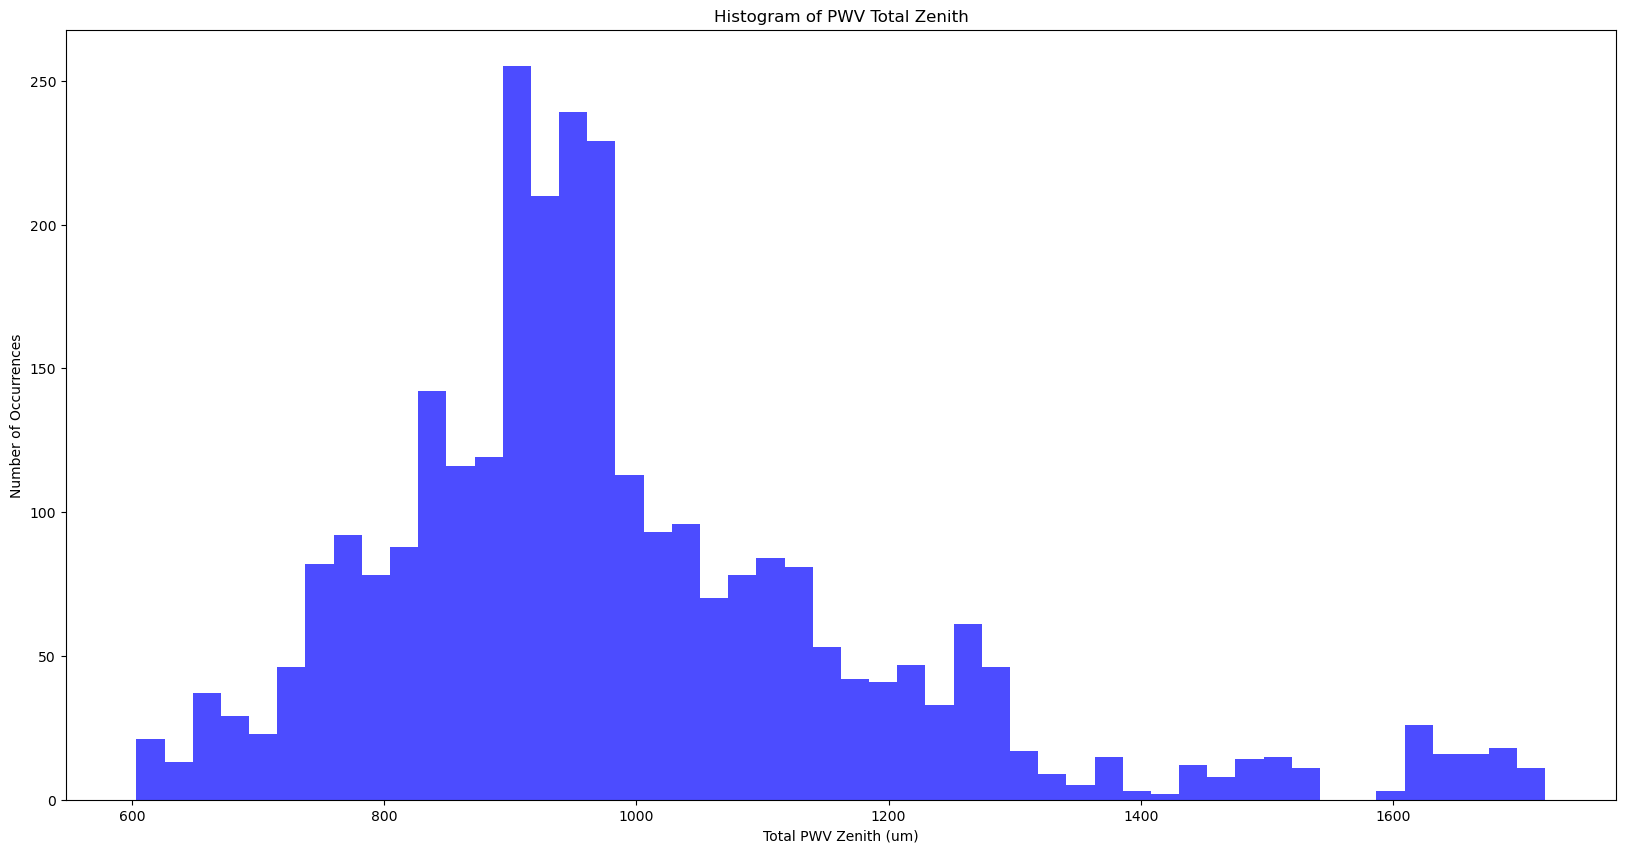

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

#read the data from the CSV file
data = pd.read_csv('saveCSV/time_pwv_2401.csv', dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})

# Convert 'DATE(YYYYMMDD)' and 'START TIME(HHMMSS.Microsec)' to a datetime object
data['TIME'] = pd.to_datetime(data['DATE(YYYYMMDD)'] + ' ' + data['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')

n = 200
#print(data['TIME'][0:10],"\n", data['PWV TOTAL zenith'][0:10])
data = data.sort_values(by='TIME')  # sort by time
#print(data['TIME'][90:105], data['PWV TOTAL zenith'][90:105])
data['PWV TOTAL zenith'] = data['PWV TOTAL zenith'].str.replace(' um_pwv', '').astype(float)
data['PWV TOTAL line-of-sight'] = data['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '').astype(float)

# plot the data
plt.figure(figsize=(20, 10))
plt.plot(data['TIME'][0:], data['PWV TOTAL zenith'][0:], marker='o', linestyle='-', color='b')
plt.title('PWV Total Zenith Over Time')
plt.xlabel('Time')
plt.ylabel('Total PWV Zenith (um)')
plt.xticks(rotation=45)
plt.grid()

plt.savefig('saveCSV/pwv_total_zenith_over_time.png', bbox_inches='tight')

plt.close()

plt.figure(figsize=(20, 10))
plt.plot(data['TIME'][0:], data['PWV TOTAL line-of-sight'][0:], marker='o', linestyle='-', color='r')
plt.title('PWV Total Line-of-Sight Over Time')
plt.xlabel('Time')
plt.ylabel('Total PWV Line-of-Sight (um)')
plt.xticks(rotation=45)
plt.grid()
plt.savefig('saveCSV/pwv_total_line_of_sight_over_time.png', bbox_inches='tight')
plt.close()

plt.figure(figsize=(20, 10))
plt.hist(data['PWV TOTAL zenith'][0:], bins=50, color='blue', alpha=0.7)
plt.title('Histogram of PWV Total Zenith')
plt.xlabel('Total PWV Zenith (um)') 
plt.ylabel('Number of Occurrences')
plt.savefig('saveCSV/histogram_pwv_total_zenith.png', bbox_inches='tight')
plt.show()
plt.close()


In [2]:
import pandas as pd

#open the time_unzip_take.csv
data = pd.read_csv('saveCSV/time_unzip_take.csv', dtype={"TIME": str,"take TIME (seconds)": float})

#find the time less than 0.4 sec
filtered_data = data[data['take TIME (seconds)'] < 0.4]
#filtered_data = data[data['TIME'] == ]

print(filtered_data)

                      TIME  take TIME (seconds)
0    unzip 20240101.tar.gz               0.0012
1    delete_unneeded_files               0.1928
2    unzip 20240102.tar.gz               0.0012
3    delete_unneeded_files               0.1582
5    delete_unneeded_files               0.1998
..                     ...                  ...
777  delete_unneeded_files               0.2180
779  delete_unneeded_files               0.2181
781  delete_unneeded_files               0.2174
782     unzip 20250131.zip               0.0355
783  delete_unneeded_files               0.1743

[406 rows x 2 columns]


In [2]:
# read npy
import numpy as np

data = np.load('Proyymm.npy', allow_pickle=True)

print(len(data))  # print the number of rows


33
